In [1]:
import sys
import matplotlib.pyplot as plt
import pickle
import os
script_path = os.path.abspath("../../Library/python/cebra_analysis_helpers")
if script_path not in sys.path:
    sys.path.append(script_path)
import cebra_analysis_helpers
import os
import random

In [2]:

# global variables for extracting behavior from SLEAP data and the paths
social_foraging_data_path =  '../../data/neural/'
output_dir = f"../../data/gridsearch_results/"
trial_type_to_correct_ports = {0:"north_east",
                               1:"east_south",
                               2:"south_west",
                               3:"west_north",
                               4:"north_south",
                               5:"east_west"}
zone_to_direction = {1:"north", 2:"east", 3:"south", 4:"west"}
direction_to_zone = {"north":1, "east":2, "south":3, "west":4}
direction_to_degrees = {"south":[45,135], "east": [315,45], "north": [225,315], "west": [135,225]}
mouse_id = "73" # choose which animal we want to run CEBRA on. We use one animal but multiple sessions per animal.

In [3]:

# set up gpu
import torch
device_id = 0
print("Cuda available",torch.cuda.is_available())
print("Number of GPUs available",torch.cuda.device_count())
print("GPU name",torch.cuda.get_device_name(device_id))
torch.cuda.set_device(device_id)
if torch.cuda.is_available():
    current_device = torch.cuda.current_device()
    print(f"Using GPU: {torch.cuda.get_device_name(current_device)} (Device {current_device})")
else:
    print("CUDA is not available, running on CPU.")


Cuda available True
Number of GPUs available 1
GPU name NVIDIA GeForce RTX 4070 Ti SUPER
Using GPU: NVIDIA GeForce RTX 4070 Ti SUPER (Device 0)


In [4]:
skip_it_load_it = True # important variable to determine whether we will compute the organizing functions for organizing the neural and behavioral data
load_path = "../../data/demo_tmp_save/YC073_data_each_session.pkl"
if not skip_it_load_it:
    mouse_and_date_list, neural_data_list, conditions_dict_list, indices_of_trials_each_frame_list, m_str = cebra_analysis_helpers.get_neural_and_behavioral_data_dict(social_foraging_data_path,
                                                                                                                                                                    mouse_id, 
                                                                                                                                                                    output_dir = "../../data/demo_tmp_save/")
else:
    with open(load_path, 'rb') as f:
        neural_and_behavioral_data_dict =  pickle.load(f)
        mouse_and_date_list = neural_and_behavioral_data_dict["mouse_and_date_list"]
        neural_data_list = neural_and_behavioral_data_dict["neural_data_list"]
        conditions_dict_list = neural_and_behavioral_data_dict["conditions_dict_list"]
        indices_of_trials_each_frame_list = neural_and_behavioral_data_dict["indices_of_trials_each_frame_list"]
        m_str = f"YC0{mouse_id}"

starting ../../data/gridsearch_results/demo_YC073_bs500_tmp0.01_Miter1000_h32_lr3e-4/angle_noRZ_ITI+T_ByT_73/


pos: -99.5836 neg:  107.5796 total:  7.9960 temperature:  0.0100: 100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:04<00:00, 15.59it/s]


starting ../../data/gridsearch_results/demo_YC073_bs500_tmp0.01_Miter1000_h32_lr3e-4/distance_noRZ_ITI+T_ByT_73/


pos: -99.4320 neg:  107.2682 total:  7.8362 temperature:  0.0100: 100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:03<00:00, 15.64it/s]


starting ../../data/gridsearch_results/demo_YC073_bs500_tmp0.01_Miter1000_h32_lr3e-4/angle_noRZ_ITI+T_ByT+shift0.5_73/


pos: -99.7871 neg:  107.9182 total:  8.1311 temperature:  0.0100: 100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:06<00:00, 15.11it/s]


starting ../../data/gridsearch_results/demo_YC073_bs500_tmp0.01_Miter1000_h32_lr3e-4/distance_noRZ_ITI+T_ByT+shift0.5_73/


pos: -99.6410 neg:  107.7068 total:  8.0658 temperature:  0.0100: 100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:05<00:00, 15.26it/s]


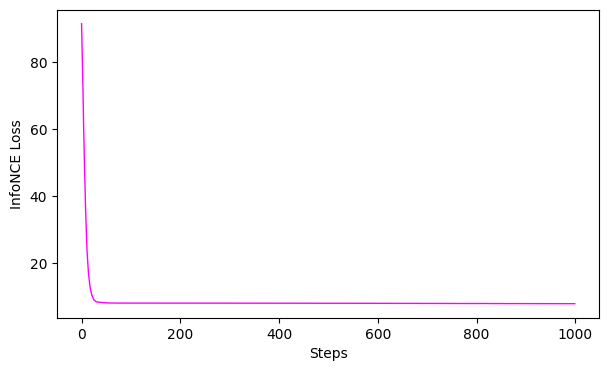

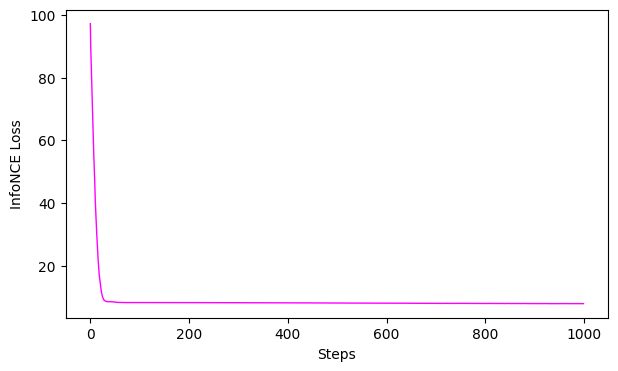

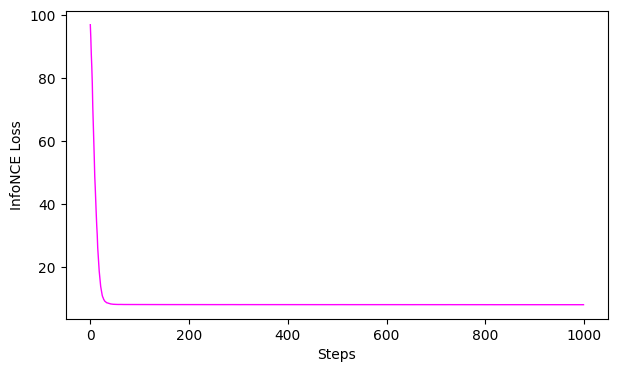

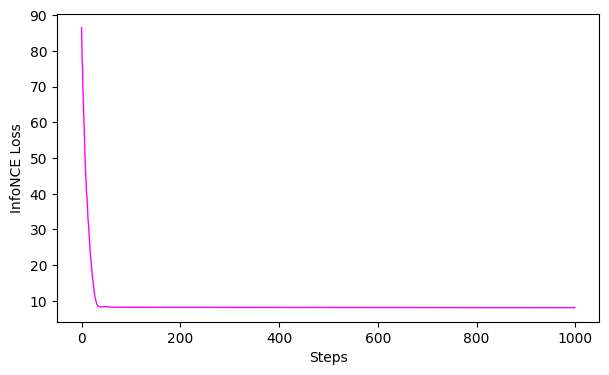

In [5]:
# select a grid to get the cebra embeddings on training and validation set data for the two behavior variables and with and without the shift condition
conditional = random.sample(["delta"],1)[0]
time_offset =  random.sample([1],1)[0]
test_size = 0.2
output_dims = 3
temperature = 0.01
temperature_mode = "constant"
max_iter = 1000
num_hidden_units = 32
lr = 0.0003
batch_size = 500
# HerbertZone means excluding a small radius around reward ports
# ITI+T means include the entire session
# ByTrial is how we are splitting up the training and validation sets by trial
# shift0.5 denotes our control condition
for approach in ["noRZ_ITI+T_ByT", "noRZ_ITI+T_ByT+shift0.5"]:  
    for behavior in ["angle", "distance"]:
        # run a model on the training set, and get embeddings on the validation and training set
        cebra_analysis_helpers.run_single_grid(output_dir,mouse_and_date_list, neural_data_list, conditions_dict_list, indices_of_trials_each_frame_list,
                        m_str, batch_size,time_offset,temperature_mode,temperature,max_iter,num_hidden_units,output_dims,lr,
                        behavior,approach, conditional, test_size, tmux_session_name = "73", device_id = device_id)
